**NOTICE:**
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from BestFit.

# 06. Batch Workflow and Reporting

This notebook demonstrates how to operationalize BestFit analyses at scale. Imagine you are a water resources engineer responsible for flood frequency studies at 50 gauge stations across a region. Instead of running each site manually (as in notebooks 00–05), you need a config-driven batch pipeline that:

1. **Loads data** from multiple sources (CSV, databases, APIs)
2. **Applies consistent analyses** (distribution fitting, model selection, forecasting, rating curves, regional analysis)
3. **Exports results** in standard formats (CSV, Excel, JSON, HTML)
4. **Tracks version** and artifacts for reproducibility
5. **Generates automated reports** summarizing key findings

## What You'll Learn

In this notebook, you will:

- Define batch configurations using YAML/JSON (extending notebook 00)
- Automate distribution fitting across multiple sites (batch from notebook 01)
- Compare estimation methods in a batch workflow (batch from notebook 02)
- Forecast streamflow for multiple sites (batch from notebook 03)
- Fit rating curves across gauges (batch from notebook 04)
- Apply regional analysis for improved estimates (batch from notebook 05)
- Consolidate output into tables, figures, and HTML reports
- Track results for audit trails and reproducibility

By the end, you'll have a template for operationalizing BestFit studies at your organization.

## Set Up

In [67]:
import pythonnet
pythonnet.load("coreclr")

import clr
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import yaml
from pathlib import Path
from datetime import datetime
from io import StringIO
from __future__ import annotations

from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_dotnet_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

print("✓ Numerics loaded from:", resolve_numerics_dll())
print("✓ BestFit loaded from:", resolve_bestfit_dll())

from RMC.BestFit import ExactData
from RMC.BestFit.Models import DataFrame, UnivariateDistribution, ARIMA, RatingCurve
from RMC.BestFit.Models.SpatialExtremes import SpatialGEV, CorrelationFunctionType, GaussianCopula

from RMC.BestFit.Models.TrendFunctions import GeneralLinearFunction
from RMC.BestFit.Estimation import BayesianAnalysis, MaximumLikelihood, OptimizationMethod
from RMC.BestFit.Analyses import FittingAnalysis, ARIMAAnalysis, RatingCurveAnalysis, SpatialGEVAnalysis


from Numerics.Data import TimeSeries, TimeInterval
from Numerics.Distributions import UnivariateDistributionType, LogPearsonTypeIII, GeneralizedExtremeValue
from Numerics.Sampling.MCMC import DEMCzs

from System import DateTime, Double
from System import Array

print("✓ Imported namespaces successfully")

# Configure plotting
plt.style.use('default')

✓ Numerics loaded from: C:\GIT\RMC-BestFit\src\RMC.BestFit\bin\Debug\net10.0\Numerics.dll
✓ BestFit loaded from: C:\GIT\RMC-BestFit\src\RMC.BestFit\bin\Debug\net10.0\RMC.BestFit.dll
✓ Imported namespaces successfully


## Configuration

To get start you must define your batch workflow with a YAML or JSON configuration file. This also helps keep our workflow tidy and organized. Below is an example that parameterizes:
- Which sites and data files to process
- Which analyses to run (distribution fitting, forecasting, etc.)
- Output locations and formats

Example YAML structure:
```yaml
metadata:
  version: 1.0
  description: "Multi-site flood frequency study - 50 gauge stations"
  timestamp: "2024-01-15"

data:
  source_type: "csv"  # csv, database, api
  directory: "../data"
  file_pattern: "{site}_daily.csv"  # {site} placeholder
  sites:
    - "A101"
    - "A102"
    - "A103"
    - "A104"

analysis:
  distribution_fitting:
    enabled: true
    distributions: ["GeneralizedExtremeValue", "LogPearsonTypeIII"]
  
  model_comparison:
    enabled: true
    method: "DIC"
  
  time_series:
    enabled: true
    models: ["AR", "ARIMA"]
  
  rating_curves:
    enabled: true
    segments: 2
  
  regional_analysis:
    enabled: true

output:
  base_directory: "../outputs"
  formats: ["csv", "json", "excel", "html"]
  create_report: true
```

Now we define some helper functions to make this process smooth and easy.

In [68]:
def load_config(config_path: str) -> dict:
    """Load batch configuration from YAML or JSON file."""
    config_path = Path(config_path)
    
    if config_path.suffix.lower() in ['.yaml', '.yml']:
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
    elif config_path.suffix.lower() == '.json':
        with open(config_path, 'r') as f:
            config = json.load(f)
    else:
        raise ValueError(f"Unsupported config format: {config_path.suffix}")
    
    return config


def create_output_directories(config: dict) -> dict:
    """Create output directory structure and return paths."""
    base = Path(config['output']['base_directory'])
    paths = {
        'base': base,
        'tables': base / 'tables',
        'figures': base / 'figures',
        'reports': base / 'reports',
        'logs': base / 'logs',
        'data': base / 'data'
    }
    
    for p in paths.values():
        p.mkdir(parents=True, exist_ok=True)
    
    return paths


def log_run(paths: dict, config: dict) -> None:
    """Log the batch run metadata for reproducibility."""
    log_entry = {
        'timestamp': datetime.now().isoformat(),
        'config_metadata': config.get('metadata', {}),
        'sites_count': len(config['data']['sites']),
        'analyses_enabled': config.get('analysis', {})
    }
    
    log_file = paths['logs'] / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
    with open(log_file, 'w') as f:
        json.dump(log_entry, f, indent=2)
    
    print(f"Run logged to {log_file}")
    return log_file

## Distributing Fitting
We will start off with a batch workflow that includes just distribution fitting for now.

In [69]:
# For demonstration, we define an inline config dict
# You could also load from a YAML file: config = load_config('batch_workflow_config_1.yaml')

config = {
    'metadata': {
        'version': '1.0',
        'description': 'Demonstration batch workflow: 4 synthetic flood frequency sites',
        'created': datetime.now().isoformat()
    },
    'data': {
        'source_type': 'synthetic',  # Could be 'csv', 'database', 'api'
        'sites': ['A101', 'A102', 'A103', 'A104'],
        'n_years': 40,
        'seed': 77,
    },
    'analysis': {
        'distribution_fitting': {
            'enabled': True,
            'distributions': ['GeneralizedExtremeValue', 'LogPearsonTypeIII']
        },
        'model_comparison': {
            'enabled': True,
            'method': 'likelihood'
        },
        'return_periods': [10, 50, 100]  # Return periods to estimate (years)
    },
    'output': {
        'base_directory': '../notebooks/outputs/batch_1',   # want outputs in the output folder we already have
        'formats': ['csv', 'json'],
        'create_report': True
    }
}

# Setup output directories
output_paths = create_output_directories(config)
print("Output directories created:")
for name, path in output_paths.items():
    print(f"  {name}: {path}")

# Log the run
log_run(output_paths, config)

print(f"Return periods: {config['analysis']['return_periods']} years")

print(f"\nConfiguration: {config['metadata']['description']}")
print(f"Sites to process: {', '.join(config['data']['sites'])}")

Output directories created:
  base: ..\notebooks\outputs\batch_1
  tables: ..\notebooks\outputs\batch_1\tables
  figures: ..\notebooks\outputs\batch_1\figures
  reports: ..\notebooks\outputs\batch_1\reports
  logs: ..\notebooks\outputs\batch_1\logs
  data: ..\notebooks\outputs\batch_1\data
Run logged to ..\notebooks\outputs\batch_1\logs\run_20260716_150731.json
Return periods: [10, 50, 100] years

Configuration: Demonstration batch workflow: 4 synthetic flood frequency sites
Sites to process: A101, A102, A103, A104


Now that we have set up our configuration and file structure for our outputs, we can get started!

In [70]:
# Since we don't have real data, here is a function to generate synthetic site data
def generate_synthetic_site_data(site_id: str, n_years: int, seed: int, site_offset: int) -> tuple:
    """Generate realistic synthetic annual peak flow data for a site."""
    rng = np.random.default_rng(seed + site_offset)
    years = np.arange(1980, 1980 + n_years)
    
    # Correlated trend + noise to simulate realistic streamflow
    base = rng.uniform(7500, 12500)
    trend = 30 * (years - years.min())
    noise = rng.normal(0, 850, len(years))
    peaks = np.maximum(500, base + trend + noise)
    
    return years, peaks


# Main batch loop - Distribution Fitting
print("\n" + "="*70)
print("BATCH PROCESSING: DISTRIBUTION FITTING")
print("="*70)

batch_results = []

for site_idx, site_id in enumerate(config['data']['sites']):
    try:
        print(f"\nProcessing {site_id}...", end=" ")
        
        # Generate site data
        years, peaks = generate_synthetic_site_data(site_id, config['data']['n_years'], config['data']['seed'], site_idx)
        
        # Create BestFit DataFrame
        df = DataFrame()
        for y, q in zip(years, peaks):
            df.ExactSeries.Add(ExactData(int(y), float(q)))
        
        # Fit GEV distribution
        site_results = {'site': site_id, 'n_years': len(peaks)}
        
        m = UnivariateDistribution(df, UnivariateDistributionType.GeneralizedExtremeValue)
        mu = float(np.mean(peaks))
        sd = float(np.std(peaks, ddof=1))
        p = convert_to_dotnet_array([mu, max(1e-6, 0.8*sd), 0.08])
        m.SetParameterValues(p)
        
        # Store results
        site_results['mean'] = mu
        site_results['std'] = sd
        site_results['log_likelihood'] = float(m.LogLikelihood(p))
        
        # Estimate return levels for each configured return period
        for rp in config['analysis']['return_periods']:
            prob = 1.0 - (1.0 / rp)
            quantile = float(m.Distribution.InverseCDF(prob))
            site_results[f'Q{rp}'] = quantile
        
        batch_results.append(site_results)
        print(f"✓ Q100={site_results['Q100']:.0f}")
        
    except Exception as e:
        print(f"✗ Error: {e}")
        batch_results.append({'site': site_id, 'error': str(e)})

# Create summary DataFrame
summary_df = pd.DataFrame(batch_results)
print("\n" + "-"*70)
print(summary_df.to_string(index=False))


BATCH PROCESSING: DISTRIBUTION FITTING

Processing A101... ✓ Q100=15079

Processing A102... ✓ Q100=12474

Processing A103... ✓ Q100=15310

Processing A104... ✓ Q100=14578

----------------------------------------------------------------------
site  n_years         mean         std  log_likelihood          Q10          Q50         Q100
A101       40 11927.668816 1023.560242     -380.152617 13614.028672 14672.161241 15079.119509
A102       40 10452.184742  656.531249     -364.288218 11533.848427 12212.555032 12473.585901
A103       40 12662.039770  860.030877     -374.810308 14078.977910 14968.057656 15309.998132
A104       40 11755.028074  916.753402     -371.332861 13265.419032 14213.137194 14577.630031


We can take our results and export them into .csv ad .json files to share them more easily and access them outside of this notebook.

In [71]:
# Export to CSV and JSON
out_dir = output_paths['tables']
summary_df.to_csv(out_dir / 'flood_frequency_batch.csv', index=False)
summary_df.to_json(out_dir / 'flood_frequency_batch.json', orient='records', indent=2)

print(f"\n✓ Saved: {out_dir / 'flood_frequency_batch.csv'}")
print(f"✓ Saved: {out_dir / 'flood_frequency_batch.json'}")

# Summary statistics
print(f"\nBatch Summary:")
print(f"  Sites processed: {len(summary_df)}")
if 'error' not in summary_df.columns or not summary_df['error'].notna().any():
    q_cols = [c for c in summary_df.columns if c.startswith('Q')]
    if q_cols:
        print(f"  Avg Q100: {summary_df['Q100'].mean():.0f} cfs")
        print(f"  Max Q100: {summary_df['Q100'].max():.0f} cfs")
        print(f"  Min Q100: {summary_df['Q100'].min():.0f} cfs")


✓ Saved: ..\notebooks\outputs\batch_1\tables\flood_frequency_batch.csv
✓ Saved: ..\notebooks\outputs\batch_1\tables\flood_frequency_batch.json

Batch Summary:
  Sites processed: 4
  Avg Q100: 14360 cfs
  Max Q100: 15310 cfs
  Min Q100: 12474 cfs


Let's take a look at our return levels by site.

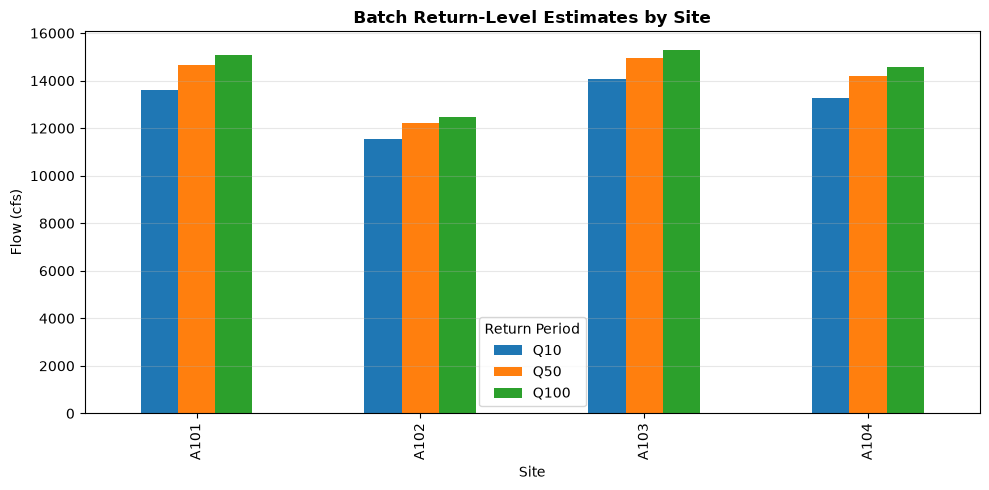

✓ Saved: ..\notebooks\outputs\batch_1\figures\return_levels_by_site.png


In [72]:
# Return levels by site
fig, ax = plt.subplots(figsize=(10, 5))
q_cols = [c for c in summary_df.columns if c.startswith('Q')]
if q_cols:
    summary_df.set_index('site')[q_cols].plot(kind='bar', ax=ax)
    ax.set_title('Batch Return-Level Estimates by Site', fontsize=12, fontweight='bold')
    ax.set_ylabel('Flow (cfs)')
    ax.set_xlabel('Site')
    ax.legend(title='Return Period')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fig.savefig(output_paths['figures'] / 'return_levels_by_site.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_paths['figures'] / 'return_levels_by_site.png'}")

## Additional Analyses
We've covered more analyses than just distribution fitting in this demo, so let's add them to our workflow.

- **Model Comparison**
    - Compare GEV vs. Log-Pearson III using likelihood-based model selection
- **Time Series Forecasting (notebook 03)**
    - AR/ARIMA model fitting for each site
    - Multi-step forecast generation
    - Ensemble predictions across methods
- **Rating Curve Fitting (notebook 04)**
    - Two-/three-segment power-law models
    - Bayesian DEMCzs parameter estimation
    - Uncertainty propagation to flow estimates
- **Regional Analysis (notebook 05)**
    - Index flood approach across sites
    - Regional frequency curves
    - Improved at-site estimates using pooled information

### Implementation Pattern
For each extension, follow this pattern:
1. Define configuration parameters
2. Loop over sites
3. Apply BestFit analysis
4. Consolidate results into site-level tables
5. Export and visualize

With so many analyses to conduct, it is best to define a helper function for each to be used in the main batch loop.

In [74]:
def fit_distributions(df: DataFrame) -> pd.DataFrame:
    """Fit a set of distributions and return a comparison table."""
    analysis = FittingAnalysis(df)
    analysis.RunAsync().Wait()

    rows = []
    for fd in analysis.FittedDistributions:

        rows.append({
            "distribution": str(fd.Distribution.Type),
            "aic": float(fd.AIC),
            "bic": float(fd.BIC)
        })

    return pd.DataFrame(rows)


def fit_arima_forecast(site_id: str, n_steps: int = 12) -> pd.DataFrame:
    """Build an ARIMA forecast for synthetic monthly flow data."""
    # Create synthetic monthly series for demonstration 
    # If we had real data, we would load it here instead of generating synthetic data
    rng = np.random.default_rng(config['data']['seed'] + hash(site_id) % 100)
    index = pd.date_range(start='2010-01-01', periods=config['data']['n_years'] * 12, freq='MS')
    values = np.maximum(0, 5000 + 25 * np.arange(len(index)) + rng.normal(0, 500, len(index)))

    ts = TimeSeries(TimeInterval.OneMonth, DateTime(1990,1,1), convert_to_dotnet_array(values))

    model = ARIMA(ts, AROrderP=1, DiffOrderD=1, MAOrderQ=1, IncludeIntercept=True, UseDefaultTrainingSteps=False)
    model.TrainingTimeSteps = ts.Count

    # MLE estimation using MaximumLikelihood class
    mle = MaximumLikelihood(model)
    mle.Estimate()

    analysis = ARIMAAnalysis(model)
    analysis.BayesianAnalysis.PRNGSeed = 1234
    analysis.BayesianAnalysis.Iterations = 10000
    analysis.WarmupIterations = 5000
    analysis.ForecastingTimeSteps = n_steps
    analysis.RunAsync().Wait()

    results = analysis.BayesianAnalysis.Results
    forecasts = analysis.AnalysisResults
    mean = []
    for h in range(analysis.ForecastingTimeSteps):
        mean.append(forecasts.MeanCurve[h])


    forecast_index = pd.date_range(start=index[-1] + pd.offsets.MonthBegin(1), periods=n_steps, freq='MS')
    return pd.DataFrame({'date': forecast_index, 'forecast': np.array(mean).astype(float)})


def fit_rating_curve(site_id: str) -> dict:
    """Fit a simple rating curve and return key parameters."""
    n_points = 20
    rng = np.random.default_rng(config['data']['seed'] + len(site_id))
    # If we had real stage-discharge data, we would load it here instead of generating synthetic data
    stage = np.linspace(1, 10, n_points)
    discharge = 50 * stage ** 1.75 + rng.normal(0, 10, n_points)

    stage_ts = TimeSeries(TimeInterval.OneMonth, DateTime(1990,1,1), convert_to_dotnet_array(stage))
    discharge_ts = TimeSeries(TimeInterval.OneMonth, DateTime(1990,1,1), convert_to_dotnet_array(discharge))

    model = RatingCurve(stage_ts, discharge_ts, numberOfSegments=1)
    mle = MaximumLikelihood(model, OptimizationMethod.MultilevelSingleLinkage)
    mle.Estimate()
    analysis = RatingCurveAnalysis(model)
    analysis.BayesianAnalysis.PRNGSeed = 123
    analysis.BayesianAnalysis.Iterations = 10000
    analysis.BayesianAnalysis.WarmupIterations = 5000
    analysis.BayesianAnalysis.ThinningInterval = 10
    analysis.BayesianAnalysis.NumberOfChains = 4
    analysis.RunAsync().Wait()

    results = analysis.BayesianAnalysis.Results


    return {
        'site': site_id,
        'rating_curve_function': 'power-law',
        'n_points': n_points,
        'dic': float(analysis.BayesianAnalysis.DIC)
    }

def apply_regional_analysis(annual_maxima,coordinates,site_ids) -> pd.DataFrame:
    """
    Run a Spatial GEV analysis across all sites simultaneously.
    """
    location = GeneralLinearFunction("Location",coordinates)
    scale = GeneralLinearFunction("Scale",coordinates)
    shape = GeneralLinearFunction("Shape")

    model = SpatialGEV(annual_maxima,coordinates,location,scale,shape)
    model.UseLogLinkForLocation = True
    model.UseLogLinkForScale = True

    analysis = SpatialGEVAnalysis(model)
    analysis.BayesianAnalysis.PRNGSeed = 456
    analysis.BayesianAnalysis.Iterations = 20000
    analysis.BayesianAnalysis.WarmupIterations = 10000
    analysis.BayesianAnalysis.ThinningInterval = 10
    analysis.BayesianAnalysis.NumberOfChains = 4

    analysis.RunAsync().Wait()
    rows = []

    for site_result in analysis.SiteResults:

        probs = list(site_result.Probabilities)
        idx100 = probs.index(0.01)
        idx500 = probs.index(0.002)

        rows.append({
            "site": site_ids[site_result.SiteIndex],
            "Q100": float(site_result.QuantileMean[idx100]),
            "Q500": float(site_result.QuantileMean[idx500])
        })

    return pd.DataFrame(rows)


# Run the full integrated batch workflow
config = load_config('batch_workflow_config_2.yaml')

# Setup output directories
output_paths = create_output_directories(config)
print("Output directories created:")
for name, path in output_paths.items():
    print(f"  {name}: {path}")

# Log the run
log_run(output_paths, config)

print(f"Return periods: {config['analysis']['return_periods']} years")

print(f"\nConfiguration: {config['metadata']['description']}")
print(f"Sites to process: {', '.join(config['data']['sites'])}")

print("\n" + "="*70)
print("RUNNING FULL BATCH WORKFLOW")
print("="*70)

mail_results = []
all_site_peaks = []
all_site_coordinates = []
workflow_results = {
    'distribution_fitting': [],
    'model_comparison': [],
    'time_series': [],
    'rating_curves': [],
    'regional_analysis': []
}

for site_id in config['data']['sites']:
    print(f"\n--- {site_id} ---")

    years, peaks = generate_synthetic_site_data(site_id, config['data']['n_years'], config['data']['seed'], len(site_id))
    all_site_peaks.append(peaks)
    site_index = len(all_site_coordinates)
    all_site_coordinates.append([ 100.0 + 10.0 * site_index, 50.0 + 5.0 * site_index])

    df_site = DataFrame()
    for y, q in zip(years, peaks):
        df_site.ExactSeries.Add(ExactData(int(y), float(q)))

    # 1) Distribution fitting
    dist_df = fit_distributions(df_site)
    best_dist = dist_df.loc[dist_df['aic'].idxmin()].to_dict()
    best_dist['site'] = site_id
    workflow_results['distribution_fitting'].append(best_dist)

    # 2) Model comparison
    workflow_results['model_comparison'].append({
        'site': site_id,
        'best_distribution': best_dist['distribution']
    })

    # 3) Time series forecasting
    forecast_df = fit_arima_forecast(site_id)
    workflow_results['time_series'].append({'site': site_id, 'forecast_rows': len(forecast_df)})
    forecast_df.to_csv(output_paths['tables'] / f'{site_id}_forecast.csv', index=False)
    print(f"Saved ARIMA forecast for {site_id}")

    # 4) Rating curve fitting
    rc_result = fit_rating_curve(site_id)
    workflow_results['rating_curves'].append(rc_result)

# 5) Regional analysis
if all_site_peaks:
    n_years = config['data']['n_years']
    n_sites = len(config['data']['sites'])

    annual_maxima = Array.CreateInstance(Double,n_years,n_sites)

    for j, peaks in enumerate(all_site_peaks):
        for i, value in enumerate(peaks):
            annual_maxima[i, j] = float(value)

    coordinates = Array.CreateInstance(Double,n_sites,2)
    for i, (x, y) in enumerate(all_site_coordinates):
        coordinates[i, 0] = float(x)
        coordinates[i, 1] = float(y)

    regional_df = apply_regional_analysis(annual_maxima,coordinates,config['data']['sites'])
    workflow_results['regional_analysis'] = (regional_df.to_dict('records'))


# Consolidate and export
for analysis_type, records in workflow_results.items():
    df_out = pd.DataFrame(records)
    if not df_out.empty:
        df_out.to_csv(output_paths['tables'] / f'{analysis_type}_batch_results.csv', index=False)
        print(f"Saved {analysis_type}_batch_results.csv")

Output directories created:
  base: ..\notebooks\outputs\batch_2
  tables: ..\notebooks\outputs\batch_2\tables
  figures: ..\notebooks\outputs\batch_2\figures
  reports: ..\notebooks\outputs\batch_2\reports
  logs: ..\notebooks\outputs\batch_2\logs
  data: ..\notebooks\outputs\batch_2\data
Run logged to ..\notebooks\outputs\batch_2\logs\run_20260716_150821.json
Return periods: [10, 25, 50, 100, 500] years

Configuration: Production batch run - Quarterly update for regional study
Sites to process: A101, A102, A103, A104, A105

RUNNING FULL BATCH WORKFLOW

--- A101 ---
Saved ARIMA forecast for A101

--- A102 ---
Saved ARIMA forecast for A102

--- A103 ---
Saved ARIMA forecast for A103

--- A104 ---
Saved ARIMA forecast for A104

--- A105 ---
Saved ARIMA forecast for A105
Saved distribution_fitting_batch_results.csv
Saved model_comparison_batch_results.csv
Saved time_series_batch_results.csv
Saved rating_curves_batch_results.csv
Saved regional_analysis_batch_results.csv


**NOTICE:**
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from BestFit.

## Best Practices for Batch Workflows

### 1. Configuration Management
- Version control configs alongside code (track `batch_config.yaml` in git)
- Parameterize everything — no hardcoded paths, site lists, or parameters
- Use environment variables for secrets (API keys, database credentials)

### 2. Error Handling
```python
try:
    # Process site
except ValueError as e:
    log_error(site_id, 'data_format_error', str(e))
except Exception as e:
    log_error(site_id, 'unknown_error', str(e))
    continue  # Don't fail the entire batch
```

### 3. Reproducibility
- Log run metadata (config, timestamp, data versions, random seeds)
- Version outputs with timestamps (e.g., `results_20240115_143022/`)
- Archive inputs alongside results for auditing

### 4. Performance
- Process in parallel when possible (multiple sites/models simultaneously)
- Cache intermediate results (preprocessed data, fitted models)
- Limit MCMC chains for quick prototyping vs. final runs

### 5. Validation
- Sanity checks: Valid ranges, realistic return levels, non-negative flows
- Data quality filters: Minimum record length, outlier detection
- Model diagnostics: Check convergence, goodness-of-fit metrics

## Summary
In this notebook you:       
$\checkmark$ Explored how to fill in a basic YAML file      
$\checkmark$ Loaded and configured a YAML file      
$\checkmark$ Defined helper functions for BestFit's various analyses        
$\checkmark$ Leveraged functions to run analysis across multiple sites simultaneously       

## Exercises
1. Create a new YAML file with at least one analysis include
2. Configure the YAML file and run the corresponding helper function(s) in a batch loop
3. Create visualizations to examine the results of your analysis

## From Exploration to Production

| Notebook | Purpose | Batch Integration |
|----------|---------|-------------------|
| **00** | Environment setup | Config management, logging |
| **01** | Distribution fitting | Loop over sites, fit GEV/LPIII |
| **02** | Model estimation | Compare MLE vs. Bayesian methods |
| **03** | Time series forecasting | ARIMA forecasts per site |
| **04** | Rating curves | Stage-discharge relationships |
| **05** | Regional analysis | Spatial GEV pooling |
| **06** | Batch workflow | Orchestrate 00-05, export reports |

Congratulations on reaching the end of this demo! You've created a scalable, reproducible batch processing framework for operationalizing flood frequency analyses. This is the major benefit of breaking BestFit down in Python. We hope BestFit can help you meet your mission critical needs in flood hazard analysis.